<a href="https://colab.research.google.com/github/ashwithareddykatta-code/sentiment-analysis-projects/blob/main/NLP_TASK_2_PRODUCT_REVIEW_ANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install nltk
!pip install wordcloud

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string

from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving product_reviews_dataset.csv to product_reviews_dataset.csv


In [ ]:
import nltk
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [ ]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
stop_words = set(stopwords.words('english'))

In [ ]:
def clean_text(text):

    text = text.lower()

    text = text.translate(str.maketrans('', '', string.punctuation))

    words = word_tokenize(text)

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [ ]:
import pandas as pd
df = pd.read_csv('product_reviews_dataset.csv')
df['clean_review'] = df['review'].apply(clean_text)

df.head()

,review,clean_review
0,The delivery is impressive and the packaging i...,delivery impressive packaging poor
1,"I like the packaging, however the durability f...",like packaging however durability feels disapp...
2,"I like the delivery, however the price feels w...",like delivery however price feels weak
3,packaging was neat but the camera is disappoin...,packaging neat camera disappointing
4,packaging was simple but the quality is solid.,packaging simple quality solid


In [ ]:
all_words = " ".join(df['clean_review'])

word_list = all_words.split()

import pandas as pd

freq = pd.Series(word_list).value_counts()

freq.head(10)

,count
price,99
packaging,89
delivery,67
durability,53
camera,48
battery,44
overall,43
quality,43
better,36
could,36


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(df['clean_review'])

dtm = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

dtm.head()

,amazing,average,bad,battery,better,camera,could,damaged,delivery,disappointing,...,performance,poor,premium,price,quality,quick,simple,solid,took,weak
0,0,0,0,0,0,0,0,0,1,0,...,0,1,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,1
3,0,0,0,0,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,1,1,0,0


In [ ]:
features = ['battery','camera','delivery','packaging','price','durability','quality']

feature_counts = {}

for f in features:
    feature_counts[f] = freq.get(f,0)

feature_counts

{'battery': np.int64(44),
 'camera': np.int64(48),
 'delivery': np.int64(67),
 'packaging': np.int64(89),
 'price': np.int64(99),
 'durability': np.int64(53),
 'quality': np.int64(43)}

In [ ]:
feature_df = pd.DataFrame(list(feature_counts.items()), columns=['Feature','Count'])

feature_df

,Feature,Count
0,battery,44
1,camera,48
2,delivery,67
3,packaging,89
4,price,99
5,durability,53
6,quality,43


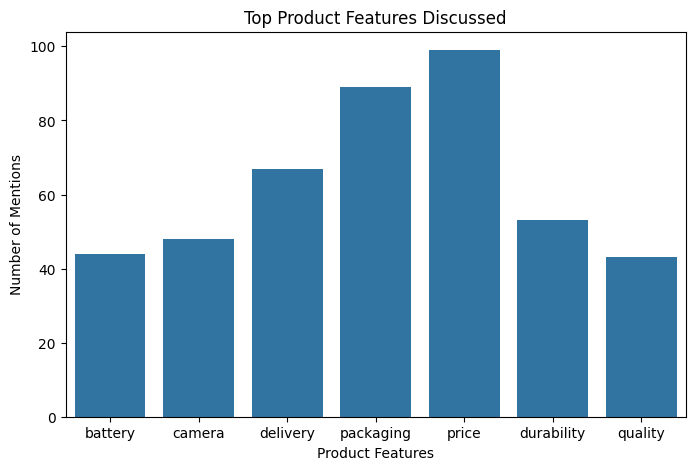

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(x='Feature', y='Count', data=feature_df)

plt.title("Top Product Features Discussed")
plt.xlabel("Product Features")
plt.ylabel("Number of Mentions")

plt.show()

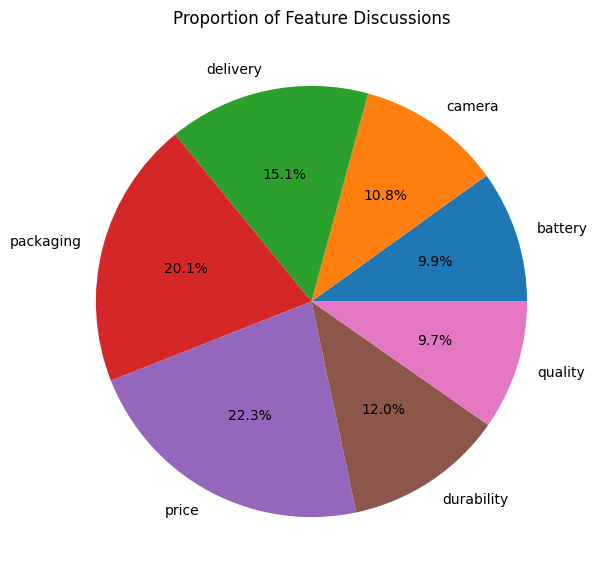

In [ ]:
plt.figure(figsize=(7,7))

plt.pie(feature_df['Count'],
        labels=feature_df['Feature'],
        autopct='%1.1f%%')

plt.title("Proportion of Feature Discussions")

plt.show()

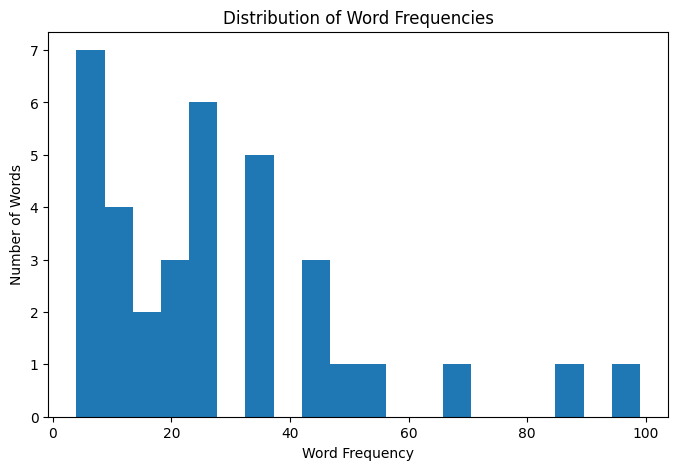

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(freq.values, bins=20)

plt.title("Distribution of Word Frequencies")
plt.xlabel("Word Frequency")
plt.ylabel("Number of Words")

plt.show()

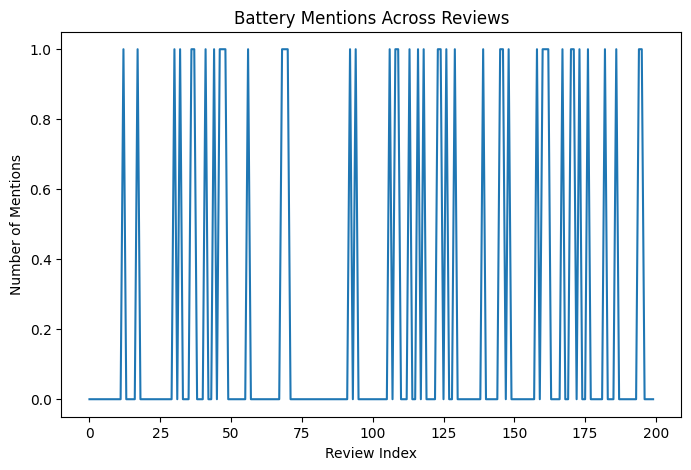

In [ ]:
battery_trend = df['clean_review'].apply(lambda x: x.count('battery'))

plt.figure(figsize=(8,5))

plt.plot(battery_trend)

plt.title("Battery Mentions Across Reviews")
plt.xlabel("Review Index")
plt.ylabel("Number of Mentions")

plt.show()

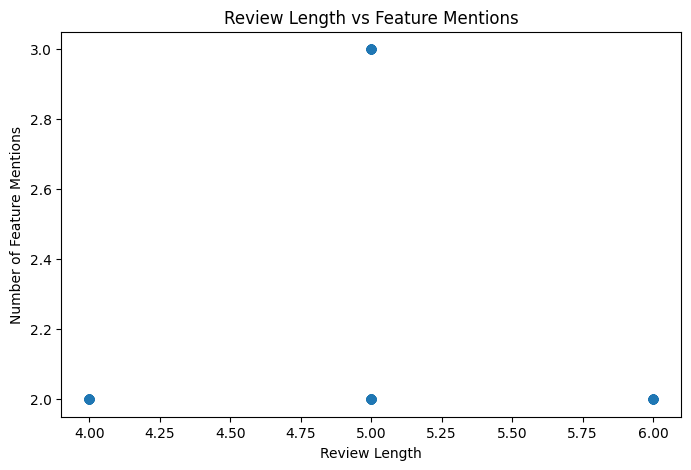

In [ ]:
features = ['battery','camera','delivery','packaging','price','durability','quality']

df['review_length'] = df['clean_review'].apply(lambda x: len(x.split()))

df['feature_mentions'] = df['clean_review'].apply(lambda x: sum(x.count(f) for f in features))

plt.figure(figsize=(8,5))

plt.scatter(df['review_length'], df['feature_mentions'])

plt.title("Review Length vs Feature Mentions")
plt.xlabel("Review Length")
plt.ylabel("Number of Feature Mentions")

plt.show()

# New section

# New section